**Student: Azizbek Ganiev (ID: 475150)**

<br> </br>
<font color='darkred' size = 7.5> <center>  <b> Quantitative strategies on high-frequency data </b> </center> </font>
<font color='darkred' size = 5> <center>  7. Optimization of a simple strategy </center> </font>
<br>
<font size = 5> <center> prof. Piotr Wójcik </center> </font>
<br> 
<font size = 5> <center>  academic year 2025/2026 </center> </font>

In [1]:
# lets load the necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import quantstats as qs
import warnings
warnings.simplefilter(action="ignore", category=UserWarning)  # ignore warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)  # ignore runtime warnings

# lets add the functions path to sys.path
import sys
sys.path.append('functions')

In [2]:
# lets load the quotations of currency futures

currencies = pd.read_parquet("currencies.parquet")

currencies.head()

,datetime,A6,E6,B6,C6,J6
0,2025-07-01 00:01:00+00:00,0.65694,1.17902,1.37390,0.734813,0.006950
1,2025-07-01 00:02:00+00:00,0.65688,1.17893,1.37396,0.734765,0.006950
2,2025-07-01 00:03:00+00:00,0.65670,1.17886,1.37386,0.734727,0.006951
3,2025-07-01 00:04:00+00:00,0.65671,1.17891,1.37397,0.734819,0.006951
4,2025-07-01 00:05:00+00:00,0.65664,1.17883,1.37391,0.734781,0.006949


In [3]:
# Lets set the datetime index

currencies['datetime'] = pd.to_datetime(currencies['datetime'])
currencies.set_index('datetime', inplace = True)

In [4]:
currencies.head()

,A6,E6,B6,C6,J6
datetime,,,,,
2025-07-01 00:01:00+00:00,0.65694,1.17902,1.37390,0.734813,0.006950
2025-07-01 00:02:00+00:00,0.65688,1.17893,1.37396,0.734765,0.006950
2025-07-01 00:03:00+00:00,0.65670,1.17886,1.37386,0.734727,0.006951
2025-07-01 00:04:00+00:00,0.65671,1.17891,1.37397,0.734819,0.006951
2025-07-01 00:05:00+00:00,0.65664,1.17883,1.37391,0.734781,0.006949


In [20]:
# data includes quotations (weighted average of bid and ask)
# of futures contracts for:
# E6 - EUR/USD
# J6 - JPY/USD
# A6 - AUD/USD
# C6 - CAD/USD
# B6 - GPB/USD

# one-minute data for one quarter (2025Q3)

# specifications of the contracts:
# E6 - point value = 125 000$, transaction cost = 10$
# J6 - point value = 12 500 000$, transaction cost = 10$
# A6 - point value = 100 000$, transaction cost = 10$
# C6 - point value = 100 000$, transaction cost = 10$
# B6 - point value = 62 500$, transaction cost = 10$

# IMPORTANT !!
# these currencies are traded almost 24 hours a day (except weekends)
# with a break between 17:00 and 18:00 (New York time - same as in the data)

In [5]:
# Let's split the data into training and test sets
# let's assume that data for the first two months (July and August) is for training
# and data for September is for testing

currencies_train = currencies[(currencies.index.month == 7) | (currencies.index.month == 8)]
currencies_test = currencies[currencies.index.month == 9]

currencies_train.tail()

,A6,E6,B6,C6,J6
datetime,,,,,
2025-08-31 23:55:00+00:00,0.65442,1.17045,1.35197,0.727966,0.006806
2025-08-31 23:56:00+00:00,0.65454,1.17059,1.35209,0.728009,0.006806
2025-08-31 23:57:00+00:00,0.65459,1.17073,1.35220,0.728035,0.006807
2025-08-31 23:58:00+00:00,0.65465,1.17075,1.35228,0.728056,0.006807
2025-08-31 23:59:00+00:00,0.65471,1.17082,1.35229,0.728051,0.006808


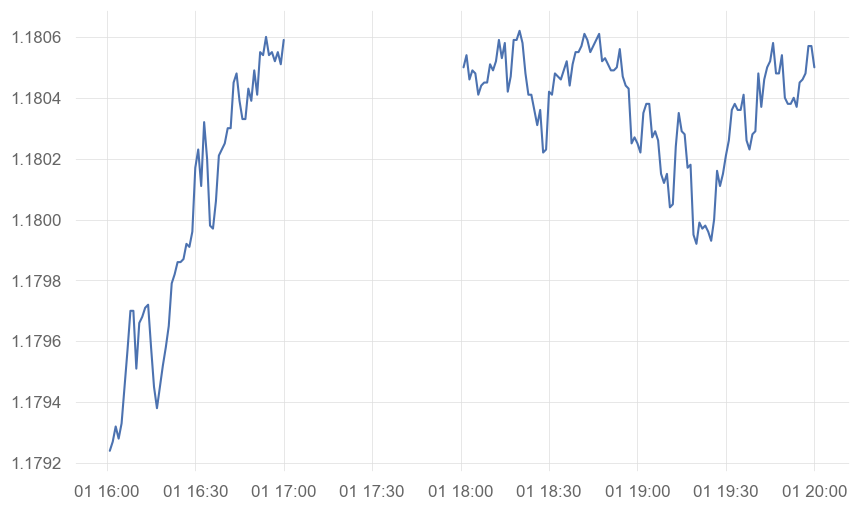

In [6]:
# Lets take E6 (EUR/USD) as an example

E6 = currencies_train['E6']

# check sample break in session

plt.figure(figsize = (10,6))
plt.plot(E6[960:1200])


C:\Users\HP\AppData\Local\Temp\ipykernel_9236\1762704899.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  E6.loc[E6.between_time("18:01", "18:05").index] = np.nan
C:\Users\HP\AppData\Local\Temp\ipykernel_9236\1762704899.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  E6.loc[E6.between_time("16:56", "17:00").index] = np.nan


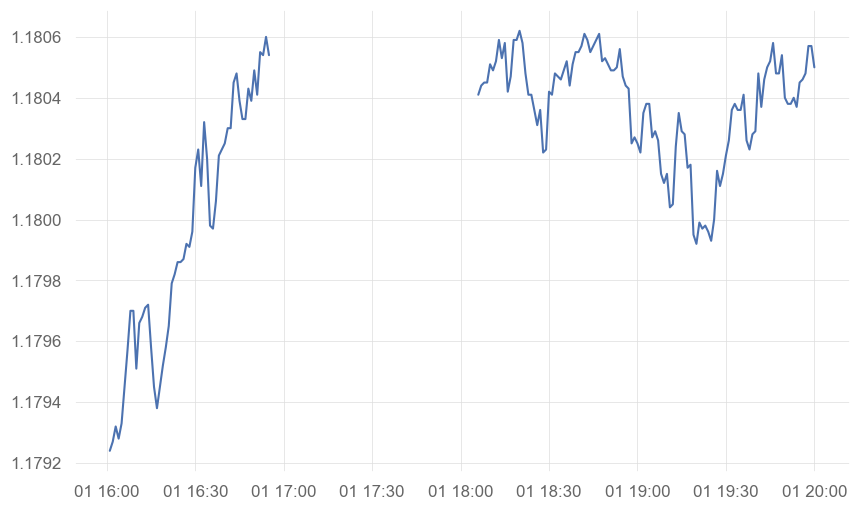

In [7]:
# initial assumptions about

# assumption 1
# we do not use the first 5 minutes of the session (18:01-18:05)
# and the last 5 minutes before the break (16:56-17:00) 
# let's insert missing data there

E6.loc[E6.between_time("18:01", "18:05").index] = np.nan
E6.loc[E6.between_time("16:56", "17:00").index] = np.nan

# let's see how the plot looks after inserting missing data

plt.figure(figsize = (10,6))
plt.plot(E6[960:1200])

# now the break in the data is longer

In [8]:
# assumption 2
# we do not trade during the first quarter of an hour after the break (18:00-18:15)
# and in the last quarter of an hour before the end of the session (16:46-17:00).
# Let's assume that we CLOSE ALL POSITIONS before the break (at 16:45).
# so finally, the position will always be 0 between 16:46 and 18:15.
# similarly as earlier, let's create an object named "pos_flat" 
# = 1 if position has to be flat (= 0) - we do not trade
# = 0 otherwise

# let's fill it first with zeros
pos_flat = np.zeros(len(E6))

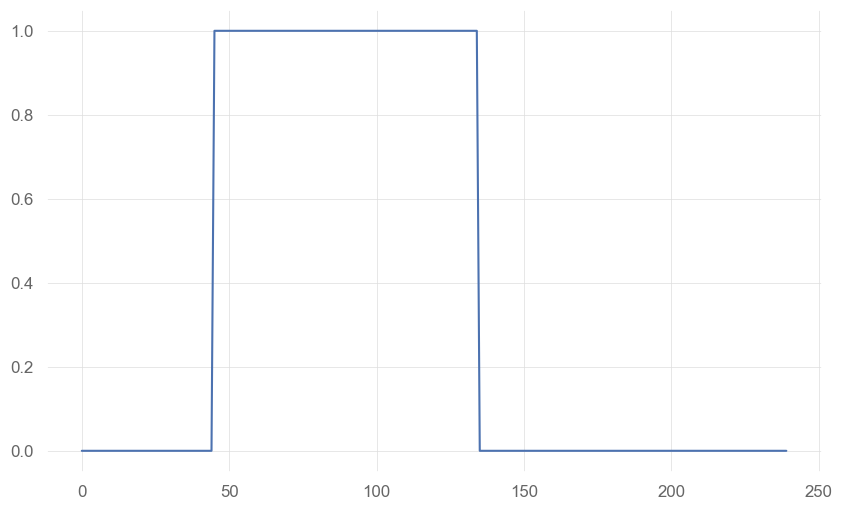

In [9]:
# put our assumptions into pos_flat
# we do not trade in the first quarter of an hour after the break (18:00-18:15)
# and in the last quarter of an hour after the break (16:46-17:00).
# Of course, we also do not trade during the break (17:00-18:00)

# Let's create a time mask based on the E6 index
breaks = (E6.index.time >= pd.to_datetime("16:46").time()) & \
          (E6.index.time <= pd.to_datetime("18:15").time())

# Assign 1 to pos_flat where the breaks mask is True
pos_flat[breaks] = 1

# let's see an example break in the session from the perspective of pos_flat

plt.figure(figsize = (10,6))
plt.plot(pos_flat[960:1200])

In [10]:
# lets check which weekdays we have data for

dweek_ = E6.index.dayofweek + 1  # Adjust so that 0 = Monday, ..., 6 = Sunday( so with +1: 1 = Monday, ..., 7 = Sunday)
print(dweek_.value_counts())

# no Saturdays in the data

datetime
4    12959
3    12957
2    12955
1    11520
5     9188
7     3771
Name: count, dtype: int64


In [11]:
# lets create a time_ object (vector of times)

time_ = E6.index.time

# and let's fill the pos_flat vector with ones for weekends

pos_flat[((dweek_ == 5) & (time_ > pd.to_datetime('17:00').time())) |      # end of Friday
          (dweek_ == 6) |                                                  # whole Saturday (just in case)
          ((dweek_ == 7) & (time_ <= pd.to_datetime('18:00').time()))] = 1 # beginning of Sunday

### Strategy 1: two intersecting moving averages

In [12]:
# we check various parameter combinations in a loop

def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

fastEMA_parameters = [15, 20, 30, 45, 60, 75, 90]
slowEMA_parameters = [90, 120, 150, 180, 240, 300, 360, 420]

# create a dataframe to store results
summary_all_2MAs = pd.DataFrame()

# Loop over different parameter combinations
for fastEMA in fastEMA_parameters:
    for slowEMA in slowEMA_parameters:
                
                # ensure that fastEMA is less than slowEMA
                if fastEMA >= slowEMA:
                    continue

                print(f"fastEMA = {fastEMA}, slowEMA = {slowEMA}")

                # We calculate the appropriate EMA
                fastEMA_values = E6.ewm(span = fastEMA).mean()
                slowEMA_values = E6.ewm(span = slowEMA).mean()

                # Insert NaNs wherever the original price is missing
                fastEMA_values[E6.isna()] = np.nan
                slowEMA_values[E6.isna()] = np.nan 

                # Calculate position for momentum strategy
                cond2b_mom_long = fastEMA_values.shift(1) > slowEMA_values.shift(1)
                
                # let's add filters that check for the presence of NaN values
                fastEMA_nonmiss = fastEMA_values.shift(1).notna()
                slowEMA_nonmiss = slowEMA_values.shift(1).notna()

                # Now we can add these conditions to our strategies
                # if any of the values is missing,
                # we cannot make a position decision

                pos_mom = np.where(fastEMA_nonmiss & slowEMA_nonmiss,
                                   np.where(cond2b_mom_long, 1, -1),
                                   np.nan)
                pos_mr = -pos_mom 

                # Set position to 0 where pos_flat is 1
                pos_mom[pos_flat == 1] = 0
                pos_mr[pos_flat == 1] = 0
                
                # Calculate gross pnl
                pnl_gross_mom = np.where(np.isnan(pos_mom * E6.diff()), 0, pos_mom * E6.diff() * 125000) 
                pnl_gross_mr = np.where(np.isnan(pos_mr * E6.diff()), 0, pos_mr * E6.diff() * 125000) 
                # point value for E6

                # Calculate number of transactions
                ntrans = np.abs(np.diff(pos_mom, prepend = 0))

                # Calculate net pnl
                pnl_net_mom = pnl_gross_mom - ntrans * 10  # cost $10 per transaction on E6
                pnl_net_mr = pnl_gross_mr - ntrans * 10  # cost $10 per transaction on E6
                  
                # Aggregate to daily data
                pnl_gross_mom = pd.Series(pnl_gross_mom)
                pnl_gross_mom.index = E6.index.time
                pnl_gross_mom_d = pnl_gross_mom.groupby(E6.index.date).sum()
                pnl_gross_mr = pd.Series(pnl_gross_mr)
                pnl_gross_mr.index = E6.index.time
                pnl_gross_mr_d = pnl_gross_mr.groupby(E6.index.date).sum()

                pnl_net_mom = pd.Series(pnl_net_mom)
                pnl_net_mom.index = E6.index.time
                pnl_net_mom_d = pnl_net_mom.groupby(E6.index.date).sum()
                pnl_net_mr = pd.Series(pnl_net_mr)
                pnl_net_mr.index = E6.index.time
                pnl_net_mr_d = pnl_net_mr.groupby(E6.index.date).sum()

                ntrans = pd.Series(ntrans)
                ntrans.index = E6.index.time
                ntrans_d = ntrans.groupby(E6.index.date).sum()

                # Calculate Sharpe Ratio and PnL
                gross_SR_mom = mySR(pnl_gross_mom_d, scale=252)
                net_SR_mom = mySR(pnl_net_mom_d, scale=252)
                gross_PnL_mom = pnl_gross_mom_d.sum()
                net_PnL_mom = pnl_net_mom_d.sum()
                gross_SR_mr = mySR(pnl_gross_mr_d, scale=252)
                net_SR_mr = mySR(pnl_net_mr_d, scale=252)
                gross_PnL_mr = pnl_gross_mr_d.sum()
                net_PnL_mr = pnl_net_mr_d.sum()

                av_daily_ntrans = ntrans_d.mean()

                # Collect necessary results into one object
                summary = pd.DataFrame({
                    'fastEMA': fastEMA,
                    'slowEMA': slowEMA,
                    'period': '2025Q3',
                    'gross_SR_mom': gross_SR_mom,
                    'net_SR_mom': net_SR_mom,
                    'gross_PnL_mom': gross_PnL_mom,
                    'net_PnL_mom': net_PnL_mom,
                    'gross_SR_mr': gross_SR_mr,
                    'net_SR_mr': net_SR_mr,
                    'gross_PnL_mr': gross_PnL_mr,
                    'net_PnL_mr': net_PnL_mr,
                    'av_daily_ntrans': av_daily_ntrans
                }, index=[0])

                # Append results to the summary
                summary_all_2MAs = pd.concat([summary_all_2MAs, summary], ignore_index=True)

fastEMA = 15, slowEMA = 90
fastEMA = 15, slowEMA = 120
fastEMA = 15, slowEMA = 150
fastEMA = 15, slowEMA = 180
fastEMA = 15, slowEMA = 240
fastEMA = 15, slowEMA = 300
fastEMA = 15, slowEMA = 360
fastEMA = 15, slowEMA = 420
fastEMA = 20, slowEMA = 90
fastEMA = 20, slowEMA = 120
fastEMA = 20, slowEMA = 150
fastEMA = 20, slowEMA = 180
fastEMA = 20, slowEMA = 240
fastEMA = 20, slowEMA = 300
fastEMA = 20, slowEMA = 360
fastEMA = 20, slowEMA = 420
fastEMA = 30, slowEMA = 90
fastEMA = 30, slowEMA = 120
fastEMA = 30, slowEMA = 150
fastEMA = 30, slowEMA = 180
fastEMA = 30, slowEMA = 240
fastEMA = 30, slowEMA = 300
fastEMA = 30, slowEMA = 360
fastEMA = 30, slowEMA = 420
fastEMA = 45, slowEMA = 90
fastEMA = 45, slowEMA = 120
fastEMA = 45, slowEMA = 150
fastEMA = 45, slowEMA = 180
fastEMA = 45, slowEMA = 240
fastEMA = 45, slowEMA = 300
fastEMA = 45, slowEMA = 360
fastEMA = 45, slowEMA = 420
fastEMA = 60, slowEMA = 90
fastEMA = 60, slowEMA = 120
fastEMA = 60, slowEMA = 150
fastEMA = 60, slowEMA = 1

In [13]:
# lets see top 5 stategies with respect to net_SR_mr
summary_all_2MAs.sort_values(by = 'net_SR_mr',
                            ascending = False).head(5)

,fastEMA,slowEMA,period,gross_SR_mom,net_SR_mom,gross_PnL_mom,net_PnL_mom,gross_SR_mr,net_SR_mr,gross_PnL_mr,net_PnL_mr,av_daily_ntrans
54,90,420,2025Q3,0.556943,-1.864757,1090.0,-3781.25,-0.556943,-3.132304,-1090.0,-5938.75,9.169811
47,75,420,2025Q3,0.696816,-1.863804,1385.0,-3866.25,-0.696816,-3.459843,-1385.0,-6613.75,9.886792
44,75,240,2025Q3,0.364396,-2.505579,745.0,-5366.25,-0.364396,-3.487748,-745.0,-6833.75,11.509434
31,45,420,2025Q3,0.321648,-2.715375,662.5,-5868.75,-0.321648,-3.629808,-662.5,-7171.25,12.301887
50,90,180,2025Q3,0.386670,-2.781942,772.5,-5798.75,-0.386670,-3.796595,-772.5,-7321.25,12.377358


In [14]:
# lets import a function written by the lecturer
# to visualize the strategy results in a form of a heatmap
from functions.plot_heatmap import plot_heatmap

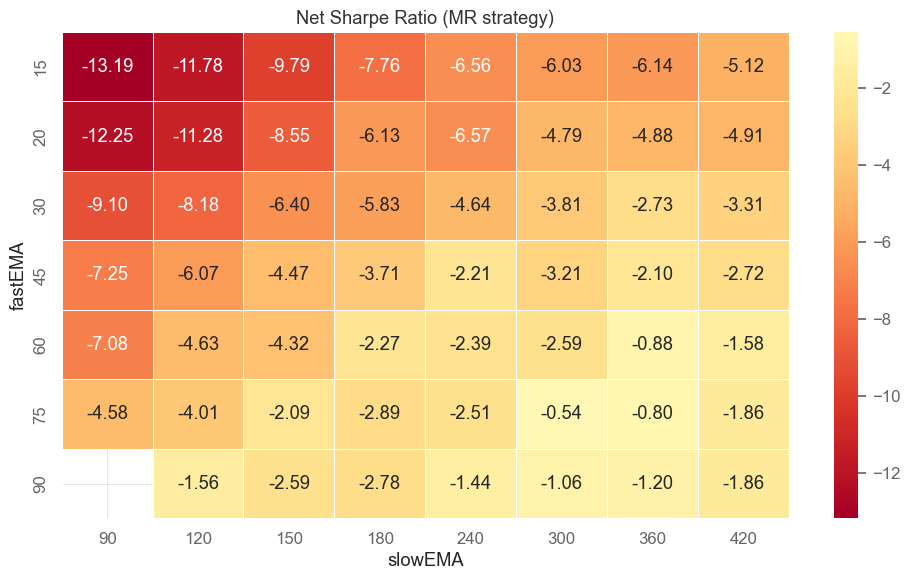

In [15]:
# we wil use it to visualize net SR values
# for the mean reversion strategy (MR)

plot_heatmap(
    summary_all_2MAs,
    value_col = 'net_SR_mom',
    index_col = 'fastEMA',
    columns_col = 'slowEMA',
    title = 'Net Sharpe Ratio (MR strategy)'
)

# none of the parameter combinations
# provides a positive net SR value

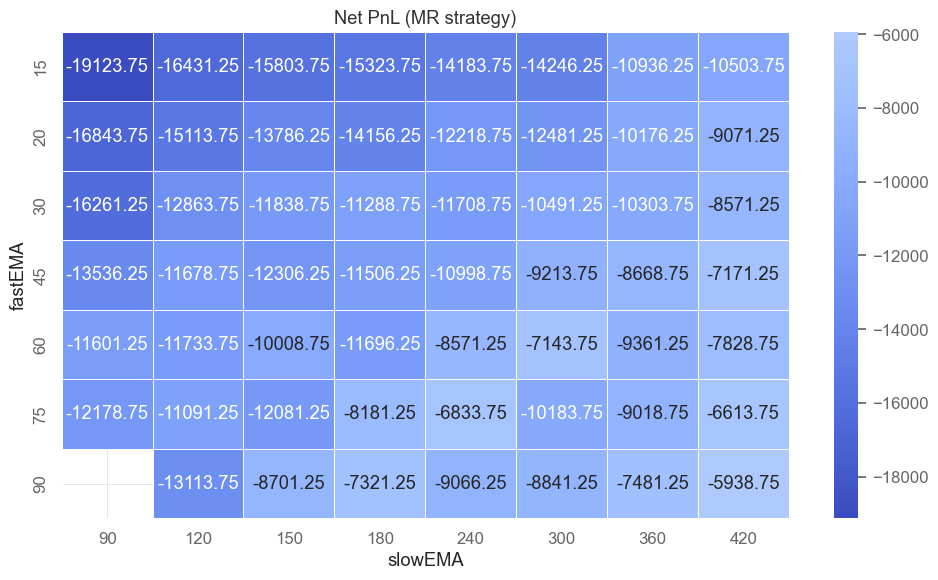

In [16]:
# lets see how it looks for the mean reversion strategy PnL

plot_heatmap(
    summary_all_2MAs,
    value_col = 'net_PnL_mr',
    index_col = 'fastEMA',
    columns_col = 'slowEMA',
    cmap = "coolwarm",
    title = 'Net PnL (MR strategy)'
)

### Strategy 2: volatility breakout

In [17]:
# lets use fastEMA as the strategy signal
# and use slowEMA+/-m*std as volatility boundaries

from functions.position_VB import positionVB

# we check various parameter combinations in a loop

signalEMA_parameters = [20, 30, 45, 60, 75, 90]
slowEMA_parameters = [90, 120, 150, 180, 240]
volat_sd_parameters = [60, 90, 120]
m_parameters = [1, 2, 3]

# create a dataframe to store results
summary_all_breakout = pd.DataFrame()

# loop over different parameter combinations
for signalEMA in signalEMA_parameters:
    print(f"signalEMA = {signalEMA}")
    for slowEMA in slowEMA_parameters:
        for volat_sd in volat_sd_parameters:
            for m in m_parameters:
               
                # We calculate the appropriate EMA
                signalEMA_values = E6.ewm(span = signalEMA).mean().to_numpy()
                slowEMA_values = E6.ewm(span = slowEMA).mean().to_numpy()
                                
                # We calculate the standard deviation
                volat_sd_values = E6.rolling(window = volat_sd).std().to_numpy()

                # Insert NaNs wherever the original price is missing
                signalEMA_values[E6.isna()] = np.nan
                slowEMA_values[E6.isna()] = np.nan 
                volat_sd_values[E6.isna()] = np.nan 

                # Calculate position for momentum strategy
                pos_mom = positionVB(signal = signalEMA_values, 
                                     lower = slowEMA_values - m * volat_sd_values,
                                     upper = slowEMA_values + m * volat_sd_values,
                                     pos_flat = pos_flat,
                                     strategy = "mom")
                
                pos_mr = -pos_mom 

                # Calculate gross pnl
                pnl_gross_mom = np.where(np.isnan(pos_mom * E6.diff()), 0, pos_mom * E6.diff() * 125000) 
                pnl_gross_mr = np.where(np.isnan(pos_mr * E6.diff()), 0, pos_mr * E6.diff() * 125000) 
                # point value for E6

                # Calculate number of transactions
                ntrans = np.abs(np.diff(pos_mom, prepend = 0))

                # Calculate net pnl
                pnl_net_mom = pnl_gross_mom - ntrans * 10  # cost $10 per transaction on E6
                pnl_net_mr = pnl_gross_mr - ntrans * 10  # cost $10 per transaction on E6
                  
                # Aggregate to daily data
                pnl_gross_mom = pd.Series(pnl_gross_mom)
                pnl_gross_mom.index = E6.index.time
                pnl_gross_mom_d = pnl_gross_mom.groupby(E6.index.date).sum()
                pnl_gross_mr = pd.Series(pnl_gross_mr)
                pnl_gross_mr.index = E6.index.time
                pnl_gross_mr_d = pnl_gross_mr.groupby(E6.index.date).sum()

                pnl_net_mom = pd.Series(pnl_net_mom)
                pnl_net_mom.index = E6.index.time
                pnl_net_mom_d = pnl_net_mom.groupby(E6.index.date).sum()
                pnl_net_mr = pd.Series(pnl_net_mr)
                pnl_net_mr.index = E6.index.time
                pnl_net_mr_d = pnl_net_mr.groupby(E6.index.date).sum()

                ntrans = pd.Series(ntrans)
                ntrans.index = E6.index.time
                ntrans_d = ntrans.groupby(E6.index.date).sum()

                # Calculate Sharpe Ratio and PnL
                gross_SR_mom = mySR(pnl_gross_mom_d, scale=252)
                net_SR_mom = mySR(pnl_net_mom_d, scale=252)
                gross_PnL_mom = pnl_gross_mom_d.sum()
                net_PnL_mom = pnl_net_mom_d.sum()
                gross_SR_mr = mySR(pnl_gross_mr_d, scale=252)
                net_SR_mr = mySR(pnl_net_mr_d, scale=252)
                gross_PnL_mr = pnl_gross_mr_d.sum()
                net_PnL_mr = pnl_net_mr_d.sum()

                av_daily_ntrans = ntrans_d.mean()

                # Collect the necessary results into one object
                summary = pd.DataFrame({
                    'signalEMA': signalEMA,
                    'slowEMA': slowEMA,
                    'volat_sd': volat_sd,
                    'm': m,
                    'period': '2025Q3',
                    'gross_SR_mom': gross_SR_mom,
                    'net_SR_mom': net_SR_mom,
                    'gross_PnL_mom': gross_PnL_mom,
                    'net_PnL_mom': net_PnL_mom,
                    'gross_SR_mr': gross_SR_mr,
                    'net_SR_mr': net_SR_mr,
                    'gross_PnL_mr': gross_PnL_mr,
                    'net_PnL_mr': net_PnL_mr,
                    'av_daily_ntrans': av_daily_ntrans
                }, index=[0])

                # Append the results to the summary
                summary_all_breakout = pd.concat([summary_all_breakout, summary], ignore_index=True)

    # it takes a while
    # ca 2.5 minutes

signalEMA = 20
signalEMA = 30
signalEMA = 45
signalEMA = 60
signalEMA = 75
signalEMA = 90


In [18]:
# check 10 strategies with the best net_SR_mr

summary_all_breakout.sort_values(by = 'net_SR_mr', 
                                 ascending = False).head(10)

,signalEMA,slowEMA,volat_sd,m,period,gross_SR_mom,net_SR_mom,gross_PnL_mom,net_PnL_mom,gross_SR_mr,net_SR_mr,gross_PnL_mr,net_PnL_mr,av_daily_ntrans
34,20,180,120,2,2025Q3,-3.621237,-4.259310,-7368.75,-8768.75,3.621237,2.966466,7368.75,5968.75,2.641509
41,20,240,90,3,2025Q3,-3.711346,-4.463872,-6047.50,-7387.50,3.711346,2.932402,6047.50,4707.50,2.528302
88,30,240,120,2,2025Q3,-3.520322,-4.194419,-7257.50,-8737.50,3.520322,2.830560,7257.50,5777.50,2.792453
178,60,240,120,2,2025Q3,-3.621270,-4.410673,-4401.25,-5461.25,3.621270,2.798320,4401.25,3341.25,2.000000
191,75,120,60,3,2025Q3,-2.838911,-3.001217,-1073.75,-1153.75,2.838911,2.667564,1073.75,993.75,0.150943
105,45,120,120,1,2025Q3,-3.248904,-3.825239,-5601.25,-6681.25,3.248904,2.655543,5601.25,4521.25,2.037736
166,60,180,90,2,2025Q3,-3.241758,-3.908310,-4658.75,-5698.75,3.241758,2.553213,4658.75,3618.75,1.962264
258,90,180,120,1,2025Q3,-3.340315,-4.143134,-4452.50,-5612.50,3.340315,2.508243,4452.50,3292.50,2.188679
133,45,240,120,2,2025Q3,-3.420858,-4.296567,-4427.50,-5667.50,3.420858,2.508086,4427.50,3187.50,2.339623
176,60,240,90,3,2025Q3,-3.104510,-3.726690,-4247.50,-5167.50,3.104510,2.463329,4247.50,3327.50,1.735849


In [19]:
# the same for momentum

summary_all_breakout.sort_values(by = 'net_SR_mom',
                                 ascending = False).head(10)

,signalEMA,slowEMA,volat_sd,m,period,gross_SR_mom,net_SR_mom,gross_PnL_mom,net_PnL_mom,gross_SR_mr,net_SR_mr,gross_PnL_mr,net_PnL_mr,av_daily_ntrans
80,30,180,120,3,2025Q3,2.619997,2.404288,1183.75,1063.75,-2.619997,-2.822166,-1183.75,-1303.75,0.226415
240,90,120,120,1,2025Q3,2.201398,2.201398,116.25,96.25,-2.201398,-2.201398,-116.25,-136.25,0.037736
61,30,120,120,2,2025Q3,2.201398,2.201398,52.50,32.50,-2.201398,-2.201398,-52.50,-72.50,0.037736
161,60,150,120,3,2025Q3,2.201398,2.201398,52.50,32.50,-2.201398,-2.201398,-52.50,-72.50,0.037736
96,45,90,120,1,2025Q3,2.201398,2.201398,52.50,32.50,-2.201398,-2.201398,-52.50,-72.50,0.037736
151,60,120,120,2,2025Q3,2.201398,2.201398,52.50,32.50,-2.201398,-2.201398,-52.50,-72.50,0.037736
206,75,150,120,3,2025Q3,2.201398,2.201398,35.00,15.00,-2.201398,-2.201398,-35.00,-55.00,0.037736
71,30,150,120,3,2025Q3,2.201398,2.201398,33.75,13.75,-2.201398,-2.201398,-33.75,-53.75,0.037736
250,90,150,120,2,2025Q3,2.201398,2.201398,42.50,22.50,-2.201398,-2.201398,-42.50,-62.50,0.037736
26,20,150,120,3,2025Q3,2.201398,2.201398,36.25,16.25,-2.201398,-2.201398,-36.25,-56.25,0.037736


In [21]:
# summarize the results for the mr strategy
# in the form of a heatmap

# here we have four parameters
# signalEMA, slowEMA, volat_sd and m,
# so to present the results in the form of a heatmap,
# we need to combine them in pairs

summary_all_breakout["signalEMA_slowEMA"] = (
    summary_all_breakout["signalEMA"].astype(int).astype(str).str.zfill(3) + "_" +
    summary_all_breakout["slowEMA"].astype(int).astype(str).str.zfill(3)
)

summary_all_breakout["volat_sd_m"] = (
    summary_all_breakout["volat_sd"].astype(int).astype(str).str.zfill(3) + "_" +
    summary_all_breakout["m"].astype(str)
)

summary_all_breakout.head()


,signalEMA,slowEMA,volat_sd,m,period,gross_SR_mom,net_SR_mom,gross_PnL_mom,net_PnL_mom,gross_SR_mr,net_SR_mr,gross_PnL_mr,net_PnL_mr,av_daily_ntrans,signalEMA_slowEMA,volat_sd_m
0,20,90,60,1,2025Q3,0.634766,-1.807507,1242.50,-3687.50,-0.634766,-3.277214,-1242.50,-6172.50,9.301887,020_090,060_1
1,20,90,60,2,2025Q3,0.554292,-0.010094,1021.25,-18.75,-0.554292,-1.127421,-1021.25,-2061.25,1.962264,020_090,060_2
2,20,90,60,3,2025Q3,-0.948394,-1.359925,-318.75,-458.75,0.948394,0.531800,318.75,178.75,0.264151,020_090,060_3
3,20,90,90,1,2025Q3,1.811271,-0.299235,3592.50,-617.50,-1.811271,-4.084996,-3592.50,-7802.50,7.943396,020_090,090_1
4,20,90,90,2,2025Q3,-1.977509,-2.523756,-135.00,-195.00,1.977509,1.212338,135.00,75.00,0.113208,020_090,090_2


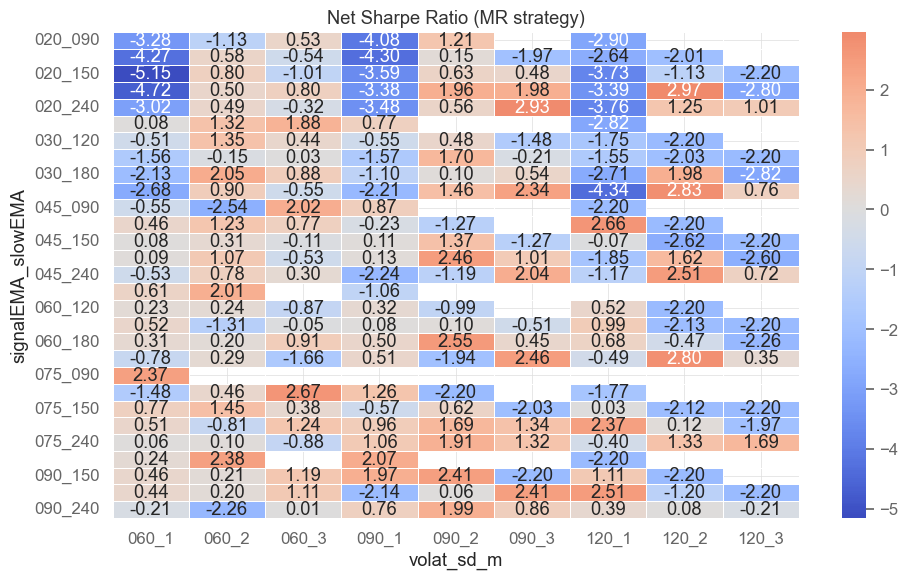

In [22]:
# now we can plot the heatmap
plot_heatmap(
    summary_all_breakout,
    value_col = 'net_SR_mr',
    index_col = 'signalEMA_slowEMA',
    columns_col = 'volat_sd_m',
    title = 'Net Sharpe Ratio (MR strategy)',
    cmap = "coolwarm"
)

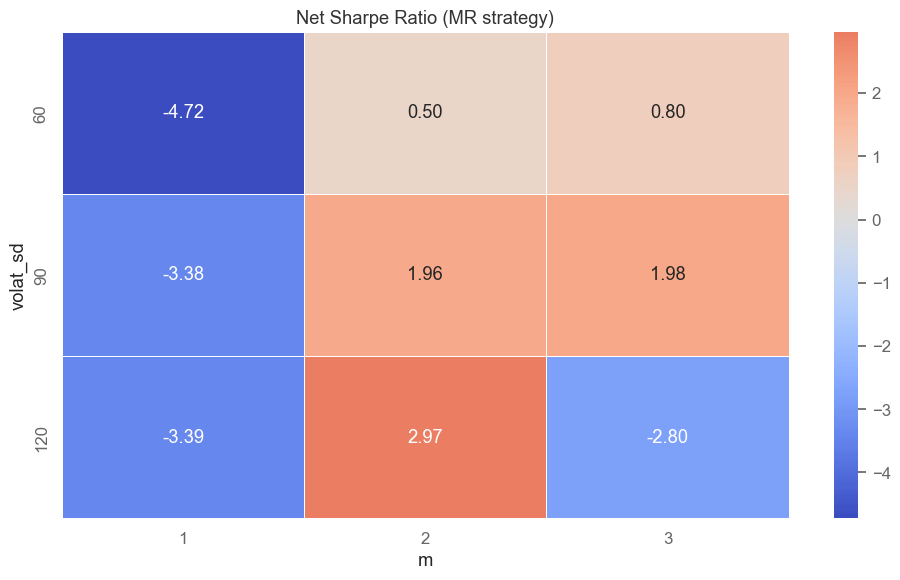

In [23]:
# the highest net SR are for signalEMA = 20 and slowEMA = 180

# let's check the sensitivity analysis of SR to m and volat_sd

# we select only rows with values of signalEMA and slowEMA
summary_all_breakout_selected = summary_all_breakout[
    (summary_all_breakout['signalEMA'] == 20) & (summary_all_breakout['slowEMA'] == 180)
]

# and we create a heatmap for them
plot_heatmap(
    summary_all_breakout_selected,
    value_col = 'net_SR_mr',
    index_col = 'volat_sd',
    columns_col = 'm',
    title = 'Net Sharpe Ratio (MR strategy)',
    cmap = "coolwarm"
)

# wygląda trochę jak anomalia, bo wokół wartości są sporo niższe

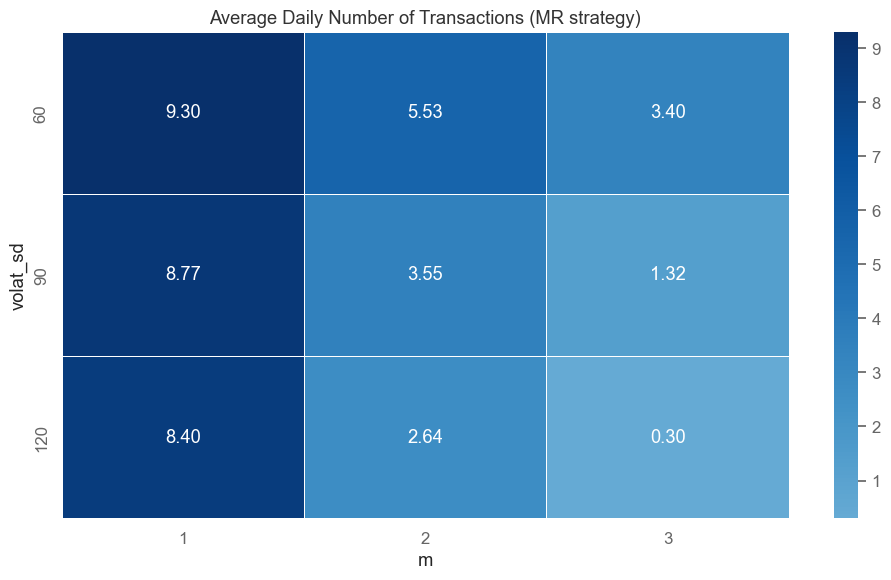

In [24]:
# heatmap plot can also be used to analyze transaction frequency

plot_heatmap(
    summary_all_breakout_selected,
    value_col = 'av_daily_ntrans',
    index_col = 'volat_sd',
    columns_col = 'm',
    title = 'Average Daily Number of Transactions (MR strategy)',
    cmap = "Blues")

    # in line with expectations
    # the larger the m, the fewer the transactions

# Exercises 7

# Exercise 7.1

Check the profitability of the same strategy on the test data for E6.

* Is the best-performing combination still profitable?
* How does its test net SR differ from that in the training data?
* Use graphs to verify the sensitivity of the results to the parameters.

In [36]:
# Solution to Exercise 7.1: Test the best-performing strategy on E6 test data

# Find best parameters from training
best_row = summary_all_breakout.sort_values(by='net_SR_mr', ascending=False).iloc[0]
best_params = {
    'signalEMA': int(best_row['signalEMA']),
    'slowEMA': int(best_row['slowEMA']),
    'volat_sd': int(best_row['volat_sd']),
    'm': int(best_row['m'])
}
print(best_params)

{'signalEMA': 20, 'slowEMA': 180, 'volat_sd': 120, 'm': 2}


In [37]:

# 2. Prepare E6 test data

E6_test = currencies_test['E6']



# 3. Recreate pos_flat for test data (same trading time rules)
pos_flat_test = np.zeros(len(E6_test))
dweek_test = E6_test.index.dayofweek + 1
# Time vector
time_test = E6_test.index.time
# Trading breaks and weekends
pos_flat_test[((dweek_test == 5) & (time_test > pd.to_datetime('17:00').time())) |
              (dweek_test == 6) |
              ((dweek_test == 7) & (time_test <= pd.to_datetime('18:00').time()))] = 1
breaks_test = (E6_test.index.time >= pd.to_datetime("16:46").time()) & (E6_test.index.time <= pd.to_datetime("18:15").time())
pos_flat_test[breaks_test] = 1




In [38]:

#4. Apply the Best Strategy to the Test Data
#Calculate the EMAs, volatility, and positions using the best parameters:
from functions.position_VB import positionVB

signalEMA = best_params['signalEMA']
slowEMA = best_params['slowEMA']
volat_sd = best_params['volat_sd']
m = best_params['m']

signalEMA_values = E6_test.ewm(span=signalEMA).mean().to_numpy()
slowEMA_values = E6_test.ewm(span=slowEMA).mean().to_numpy()
volat_sd_values = E6_test.rolling(window=volat_sd).std().to_numpy()

signalEMA_values[E6_test.isna()] = np.nan
slowEMA_values[E6_test.isna()] = np.nan
volat_sd_values[E6_test.isna()] = np.nan

pos_mr = positionVB(
    signal=signalEMA_values,
    lower=slowEMA_values - m * volat_sd_values,
    upper=slowEMA_values + m * volat_sd_values,
    pos_flat=pos_flat_test,
    strategy="mr"
)


pnl_gross_mr = np.where(np.isnan(pos_mr * E6_test.diff()), 0, pos_mr * E6_test.diff() * 125000)
ntrans = np.abs(np.diff(pos_mr, prepend=0))
pnl_net_mr = pnl_gross_mr - ntrans * 10

pnl_net_mr = pd.Series(pnl_net_mr)
pnl_net_mr.index = E6_test.index.time
pnl_net_mr_d = pnl_net_mr.groupby(E6_test.index.date).sum()

# 5. Evaluate Performance on Test Data



In [39]:
#5. Compare Training vs. Test Results
net_SR_mr_test = mySR(pnl_net_mr_d, scale=252)
print("Training Net Sharpe Ratio (MR):", best_row['net_SR_mr'])
print("Test Net Sharpe Ratio (MR):", net_SR_mr_test)

Training Net Sharpe Ratio (MR): 2.9664664659788116
Test Net Sharpe Ratio (MR): -1.127182624276243


The test Net Sharpe Ratio is less than 0, indicating that the best-performing parameter combination from the training set is not profitable on the test data.

In [40]:
### Strategy 2: volatility breakout

# lets use fastEMA as the strategy signal
# and use slowEMA+/-m*std as volatility boundaries

from functions.position_VB import positionVB

# we check various parameter combinations in a loop

signalEMA_parameters = [20, 30, 45, 60, 75, 90]
slowEMA_parameters = [90, 120, 150, 180, 240]
volat_sd_parameters = [60, 90, 120]
m_parameters = [1, 2, 3]

# create a dataframe to store results
summary_all_breakout_test = pd.DataFrame()

# loop over different parameter combinations
for signalEMA in signalEMA_parameters:
    print(f"signalEMA = {signalEMA}")
    for slowEMA in slowEMA_parameters:
        for volat_sd in volat_sd_parameters:
            for m in m_parameters:
               
                # We calculate the appropriate EMA
                signalEMA_values = E6_test.ewm(span = signalEMA).mean().to_numpy()
                slowEMA_values = E6_test.ewm(span = slowEMA).mean().to_numpy()
                                
                # We calculate the standard deviation
                volat_sd_values = E6_test.rolling(window = volat_sd).std().to_numpy()

                # Insert NaNs wherever the original price is missing
                signalEMA_values[E6_test.isna()] = np.nan
                slowEMA_values[E6_test.isna()] = np.nan 
                volat_sd_values[E6_test.isna()] = np.nan 

                # Calculate position for momentum strategy
                pos_mom = positionVB(signal = signalEMA_values, 
                                     lower = slowEMA_values - m * volat_sd_values,
                                     upper = slowEMA_values + m * volat_sd_values,
                                     pos_flat = pos_flat,
                                     strategy = "mom")
                
                pos_mr = -pos_mom 

                # Calculate gross pnl
                pnl_gross_mom = np.where(np.isnan(pos_mom * E6_test.diff()), 0, pos_mom * E6_test.diff() * 125000) 
                pnl_gross_mr = np.where(np.isnan(pos_mr * E6_test.diff()), 0, pos_mr * E6_test.diff() * 125000) 
                # point value for E6

                # Calculate number of transactions
                ntrans = np.abs(np.diff(pos_mom, prepend = 0))

                # Calculate net pnl
                pnl_net_mom = pnl_gross_mom - ntrans * 10  # cost $10 per transaction on E6
                pnl_net_mr = pnl_gross_mr - ntrans * 10  # cost $10 per transaction on E6
                  
                # Aggregate to daily data
                pnl_gross_mom = pd.Series(pnl_gross_mom)
                pnl_gross_mom.index = E6_test.index.time
                pnl_gross_mom_d = pnl_gross_mom.groupby(E6_test.index.date).sum()
                pnl_gross_mr = pd.Series(pnl_gross_mr)
                pnl_gross_mr.index = E6_test.index.time
                pnl_gross_mr_d = pnl_gross_mr.groupby(E6_test.index.date).sum()

                pnl_net_mom = pd.Series(pnl_net_mom)
                pnl_net_mom.index = E6_test.index.time
                pnl_net_mom_d = pnl_net_mom.groupby(E6_test.index.date).sum()
                pnl_net_mr = pd.Series(pnl_net_mr)
                pnl_net_mr.index = E6_test.index.time
                pnl_net_mr_d = pnl_net_mr.groupby(E6_test.index.date).sum()

                ntrans = pd.Series(ntrans)
                ntrans.index = E6_test.index.time
                ntrans_d = ntrans.groupby(E6_test.index.date).sum()

                # Calculate Sharpe Ratio and PnL
                gross_SR_mom = mySR(pnl_gross_mom_d, scale=252)
                net_SR_mom = mySR(pnl_net_mom_d, scale=252)
                gross_PnL_mom = pnl_gross_mom_d.sum()
                net_PnL_mom = pnl_net_mom_d.sum()
                gross_SR_mr = mySR(pnl_gross_mr_d, scale=252)
                net_SR_mr = mySR(pnl_net_mr_d, scale=252)
                gross_PnL_mr = pnl_gross_mr_d.sum()
                net_PnL_mr = pnl_net_mr_d.sum()

                av_daily_ntrans = ntrans_d.mean()

                # Collect the necessary results into one object
                summary_test = pd.DataFrame({
                    'signalEMA': signalEMA,
                    'slowEMA': slowEMA,
                    'volat_sd': volat_sd,
                    'm': m,
                    'period': '2025Q3',
                    'gross_SR_mom': gross_SR_mom,
                    'net_SR_mom': net_SR_mom,
                    'gross_PnL_mom': gross_PnL_mom,
                    'net_PnL_mom': net_PnL_mom,
                    'gross_SR_mr': gross_SR_mr,
                    'net_SR_mr': net_SR_mr,
                    'gross_PnL_mr': gross_PnL_mr,
                    'net_PnL_mr': net_PnL_mr,
                    'av_daily_ntrans': av_daily_ntrans
                }, index=[0])

                # Append the results to the summary
                summary_all_breakout_test = pd.concat([summary_all_breakout_test, summary_test], ignore_index=True)

    # it takes a while
    # ca 1.3 minutes

signalEMA = 20
signalEMA = 30
signalEMA = 45
signalEMA = 60
signalEMA = 75
signalEMA = 90


In [31]:
# check 10 strategies with the best net_SR_mr

summary_all_breakout_test.sort_values(by = 'net_SR_mr', 
                                 ascending = False).head(10)

,signalEMA,slowEMA,volat_sd,m,period,gross_SR_mom,net_SR_mom,gross_PnL_mom,net_PnL_mom,gross_SR_mr,net_SR_mr,gross_PnL_mr,net_PnL_mr,av_daily_ntrans
259,90,180,120,2,2025Q3,-4.490023,-4.528261,-127.50,-167.50,4.490023,4.392465,127.50,87.50,0.153846
125,45,180,120,3,2025Q3,-3.174902,-3.174902,-51.25,-71.25,3.174902,3.174902,51.25,31.25,0.076923
160,60,150,120,2,2025Q3,-3.174902,-3.174902,-51.25,-71.25,3.174902,3.174902,51.25,31.25,0.076923
80,30,180,120,3,2025Q3,-3.174902,-3.174902,-51.25,-71.25,3.174902,3.174902,51.25,31.25,0.076923
47,30,90,60,3,2025Q3,-3.174902,-3.174902,-48.75,-68.75,3.174902,3.174902,48.75,28.75,0.076923
170,60,180,120,3,2025Q3,-3.174902,-3.174902,-41.25,-61.25,3.174902,3.174902,41.25,21.25,0.076923
195,75,120,120,1,2025Q3,-3.174902,-3.174902,-41.25,-61.25,3.174902,3.174902,41.25,21.25,0.076923
205,75,150,120,2,2025Q3,-3.174902,-3.174902,-45.00,-65.00,3.174902,3.174902,45.00,25.00,0.076923
215,75,180,120,3,2025Q3,-3.174902,-3.174902,-45.00,-65.00,3.174902,3.174902,45.00,25.00,0.076923
203,75,150,90,3,2025Q3,-3.174902,-3.174902,-45.00,-65.00,3.174902,3.174902,45.00,25.00,0.076923


In [41]:
# summarize the results for the mr strategy
# in the form of a heatmap

# here we have four parameters
# signalEMA, slowEMA, volat_sd and m,
# so to present the results in the form of a heatmap,
# we need to combine them in pairs

summary_all_breakout_test["signalEMA_slowEMA"] = (
    summary_all_breakout_test["signalEMA"].astype(int).astype(str).str.zfill(3) + "_" +
    summary_all_breakout_test["slowEMA"].astype(int).astype(str).str.zfill(3)
)

summary_all_breakout_test["volat_sd_m"] = (
    summary_all_breakout_test["volat_sd"].astype(int).astype(str).str.zfill(3) + "_" +
    summary_all_breakout_test["m"].astype(str)
)

summary_all_breakout_test.head()


,signalEMA,slowEMA,volat_sd,m,period,gross_SR_mom,net_SR_mom,gross_PnL_mom,net_PnL_mom,gross_SR_mr,net_SR_mr,gross_PnL_mr,net_PnL_mr,av_daily_ntrans,signalEMA_slowEMA,volat_sd_m
0,20,90,60,1,2025Q3,-4.179809,-6.542819,-4058.75,-6598.75,4.179809,1.617573,4058.75,1518.75,9.769231,020_090,060_1
1,20,90,60,2,2025Q3,3.433398,2.379638,1438.75,998.75,-3.433398,-4.482175,-1438.75,-1878.75,1.692308,020_090,060_2
2,20,90,60,3,2025Q3,-1.826939,-2.665284,-115.00,-175.00,1.826939,0.883677,115.00,55.00,0.230769,020_090,060_3
3,20,90,90,1,2025Q3,-3.075096,-5.136323,-2991.25,-5171.25,3.075096,0.861020,2991.25,811.25,8.384615,020_090,090_1
4,20,90,90,2,2025Q3,-1.158209,-1.712558,-73.75,-113.75,1.158209,0.543941,73.75,33.75,0.153846,020_090,090_2


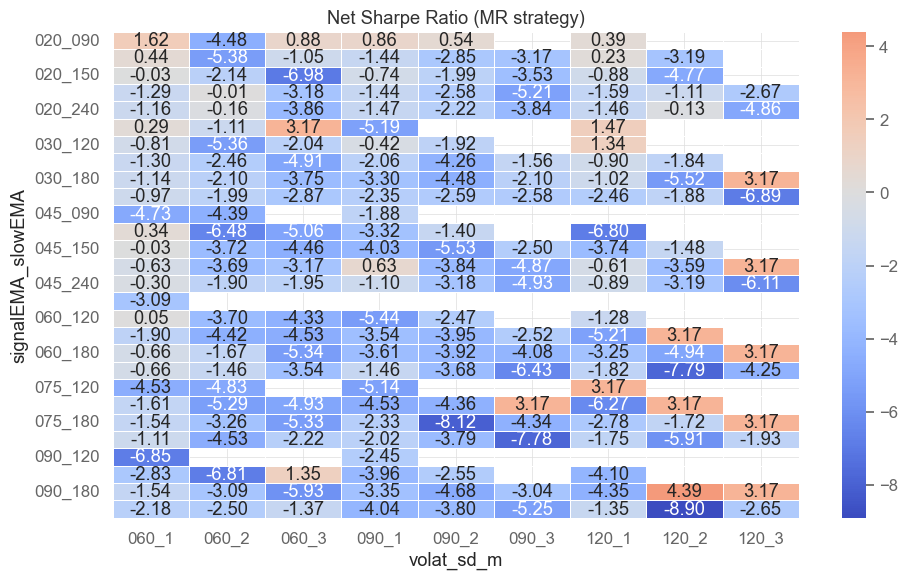

In [43]:
# now we can plot the heatmap
plot_heatmap(
    summary_all_breakout_test,
    value_col = 'net_SR_mr',
    index_col = 'signalEMA_slowEMA',
    columns_col = 'volat_sd_m',
    title = 'Net Sharpe Ratio (MR strategy)',
    cmap = "coolwarm"
)

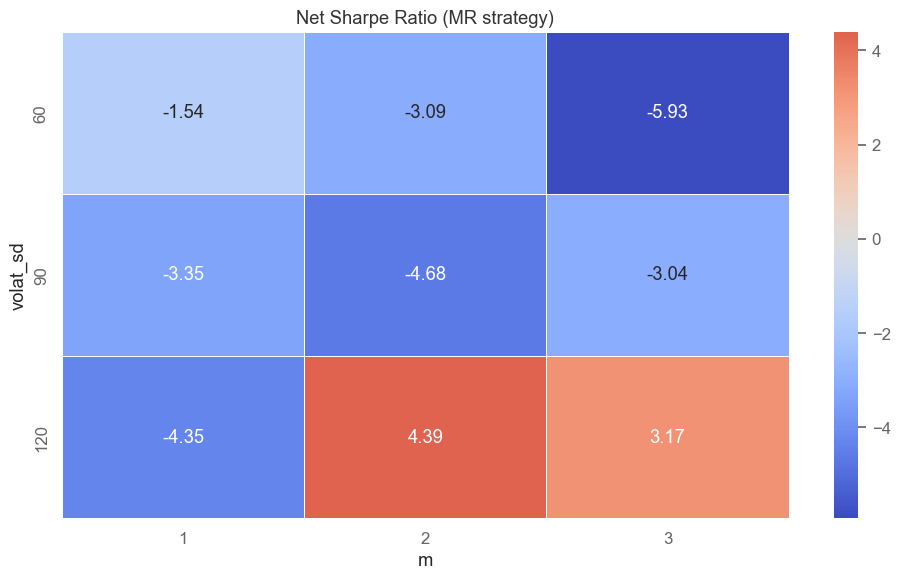

In [44]:
# the highest net SR are for signalEMA = 90 and slowEMA = 180

# let's check the sensitivity analysis of SR to m and volat_sd

# we select only rows with values of signalEMA and slowEMA
summary_all_breakout_selected_test = summary_all_breakout_test[
    (summary_all_breakout_test['signalEMA'] == 90) & (summary_all_breakout_test['slowEMA'] == 180)
]

# and we create a heatmap for them
plot_heatmap(
    summary_all_breakout_selected_test,
    value_col = 'net_SR_mr',
    index_col = 'volat_sd',
    columns_col = 'm',
    title = 'Net Sharpe Ratio (MR strategy)',
    cmap = "coolwarm"
)



#### Sensitivity analysis: Only a narrow set of parameters (e.g., signalEMA=90, slowEMA=180, volat_sd=120, m=2) yield positive net Sharpe; most others perform poorly, indicating high parameter sensitivity and risk of overfitting.

# Exercise 7.2

Perform similar analyses for another currency (other than E6).

* Use MORE parameter combinations.
* Are the conclusions for the training and test data similar to those for E6?


In [46]:
# Solution to Exercise 7.2: Volatility breakout analysis for J6 (JPY/USD) with more parameter combinations

# 1. Prepare J6 data for training and test
J6 = currencies_train['J6']
J6_test = currencies_test['J6']

# 2. Create pos_flat for J6 (same trading rules)
pos_flat_J6 = np.zeros(len(J6))
dweek_J6 = J6.index.dayofweek + 1
time_J6 = J6.index.time
pos_flat_J6[((dweek_J6 == 5) & (time_J6 > pd.to_datetime('17:00').time())) |
            (dweek_J6 == 6) |
            ((dweek_J6 == 7) & (time_J6 <= pd.to_datetime('18:00').time()))] = 1
breaks_J6 = (J6.index.time >= pd.to_datetime("16:46").time()) & (J6.index.time <= pd.to_datetime("18:15").time())
pos_flat_J6[breaks_J6] = 1

In [47]:
# 3. Define broader parameter grid
signalEMA_parameters = [10, 15, 20, 75, 90, 120]
slowEMA_parameters = [60, 90, 120, 360, 420]
volat_sd_parameters = [30, 60, 90, 120]
m_parameters = [1, 1.5, 2, 2.5, 3]

from functions.position_VB import positionVB

# 4. Grid search for training data (J6)
summary_all_breakout_J6 = []
for signalEMA in signalEMA_parameters:
    print(f"signalEMA = {signalEMA}")
    for slowEMA in slowEMA_parameters:
        if signalEMA >= slowEMA:
            continue
        for volat_sd in volat_sd_parameters:
            for m in m_parameters:
                # Calculate indicators
                sEMA = J6.ewm(span=signalEMA).mean().to_numpy()
                lEMA = J6.ewm(span=slowEMA).mean().to_numpy()
                vSD = J6.rolling(window=int(volat_sd)).std().to_numpy()
                sEMA[J6.isna()] = np.nan
                lEMA[J6.isna()] = np.nan
                vSD[J6.isna()] = np.nan
                # MOM strategy
                pos_mom = positionVB(signal=sEMA, lower=lEMA - m*vSD, upper=lEMA + m*vSD, pos_flat=pos_flat_J6, strategy="mom")
                # MR strategy
                pos_mr = -pos_mom
                # PnL
                point_value = 12500000  # for J6
                pnl_gross_mom = np.where(np.isnan(pos_mom * J6.diff()), 0, pos_mom * J6.diff() * point_value)
                pnl_gross_mr = np.where(np.isnan(pos_mr * J6.diff()), 0, pos_mr * J6.diff() * point_value)
                ntrans = np.abs(np.diff(pos_mom, prepend=0))
                pnl_net_mom = pnl_gross_mom - ntrans * 10
                pnl_net_mr = pnl_gross_mr - ntrans * 10
                # Aggregate to daily
                dates = J6.index.date
                pnl_net_mom_d = pd.Series(pnl_net_mom, index=dates).groupby(level=0).sum()
                pnl_net_mr_d = pd.Series(pnl_net_mr, index=dates).groupby(level=0).sum()
                net_SR_mom = mySR(pnl_net_mom_d, scale=252)
                net_SR_mr = mySR(pnl_net_mr_d, scale=252)
                summary_all_breakout_J6.append({'signalEMA': signalEMA, 'slowEMA': slowEMA, 'volat_sd': volat_sd, 'm': m, 'net_SR_mom': net_SR_mom, 'net_SR_mr': net_SR_mr})
summary_all_breakout_J6 = pd.DataFrame(summary_all_breakout_J6)





signalEMA = 10
signalEMA = 15
signalEMA = 15
signalEMA = 20
signalEMA = 20
signalEMA = 75
signalEMA = 75
signalEMA = 90
signalEMA = 90
signalEMA = 120
signalEMA = 120


In [48]:
# 5. Find best parameters for MR and MOM
best_mr = summary_all_breakout_J6.sort_values(by='net_SR_mr', ascending=False).iloc[0]
best_mom = summary_all_breakout_J6.sort_values(by='net_SR_mom', ascending=False).iloc[0]
print('Best MR params:', best_mr)
print('Best MOM params:', best_mom)

Best MR params: signalEMA     120.000000
slowEMA       420.000000
volat_sd      120.000000
m               2.000000
net_SR_mom     -6.074168
net_SR_mr       4.038869
Name: 477, dtype: float64
Best MOM params: signalEMA      90.000000
slowEMA       120.000000
volat_sd       60.000000
m               1.500000
net_SR_mom      4.751779
net_SR_mr      -5.521377
Name: 386, dtype: float64


In [50]:
# 6. Repeat for test data (J6_test)
pos_flat_J6_test = np.zeros(len(J6_test))
dweek_J6_test = J6_test.index.dayofweek + 1
time_J6_test = J6_test.index.time
pos_flat_J6_test[((dweek_J6_test == 5) & (time_J6_test > pd.to_datetime('17:00').time())) |
                 (dweek_J6_test == 6) |
                 ((dweek_J6_test == 7) & (time_J6_test <= pd.to_datetime('18:00').time()))] = 1
breaks_J6_test = (J6_test.index.time >= pd.to_datetime("16:46").time()) & (J6_test.index.time <= pd.to_datetime("18:15").time())
pos_flat_J6_test[breaks_J6_test] = 1

In [51]:
summary_all_breakout_J6_test = []
for signalEMA in signalEMA_parameters:
    print(f"signalEMA = {signalEMA}")
    for slowEMA in slowEMA_parameters:
        if signalEMA >= slowEMA:
            continue
        for volat_sd in volat_sd_parameters:
            for m in m_parameters:
                sEMA = J6_test.ewm(span=signalEMA).mean().to_numpy()
                lEMA = J6_test.ewm(span=slowEMA).mean().to_numpy()
                vSD = J6_test.rolling(window=int(volat_sd)).std().to_numpy()
                sEMA[J6_test.isna()] = np.nan
                lEMA[J6_test.isna()] = np.nan
                vSD[J6_test.isna()] = np.nan
                pos_mom = positionVB(signal=sEMA, lower=lEMA - m*vSD, upper=lEMA + m*vSD, pos_flat=pos_flat_J6_test, strategy="mom")
                pos_mr = -pos_mom
                point_value = 12500000
                pnl_gross_mom = np.where(np.isnan(pos_mom * J6_test.diff()), 0, pos_mom * J6_test.diff() * point_value)
                pnl_gross_mr = np.where(np.isnan(pos_mr * J6_test.diff()), 0, pos_mr * J6_test.diff() * point_value)
                ntrans = np.abs(np.diff(pos_mom, prepend=0))
                pnl_net_mom = pnl_gross_mom - ntrans * 10
                pnl_net_mr = pnl_gross_mr - ntrans * 10
                dates = J6_test.index.date
                pnl_net_mom_d = pd.Series(pnl_net_mom, index=dates).groupby(level=0).sum()
                pnl_net_mr_d = pd.Series(pnl_net_mr, index=dates).groupby(level=0).sum()
                net_SR_mom = mySR(pnl_net_mom_d, scale=252)
                net_SR_mr = mySR(pnl_net_mr_d, scale=252)
                summary_all_breakout_J6_test.append({'signalEMA': signalEMA, 'slowEMA': slowEMA, 'volat_sd': volat_sd, 'm': m, 'net_SR_mom': net_SR_mom, 'net_SR_mr': net_SR_mr})
summary_all_breakout_J6_test = pd.DataFrame(summary_all_breakout_J6_test)



signalEMA = 10
signalEMA = 15
signalEMA = 15
signalEMA = 20
signalEMA = 20
signalEMA = 75
signalEMA = 75
signalEMA = 90
signalEMA = 90
signalEMA = 120
signalEMA = 120


Best MR test params: signalEMA      10.000000
slowEMA       120.000000
volat_sd       90.000000
m               3.000000
net_SR_mom     -6.925367
net_SR_mr       6.467189
Name: 54, dtype: float64
Best MOM test params: signalEMA      90.000000
slowEMA       360.000000
volat_sd       90.000000
m               2.000000
net_SR_mom      3.740917
net_SR_mr      -7.658656
Name: 412, dtype: float64


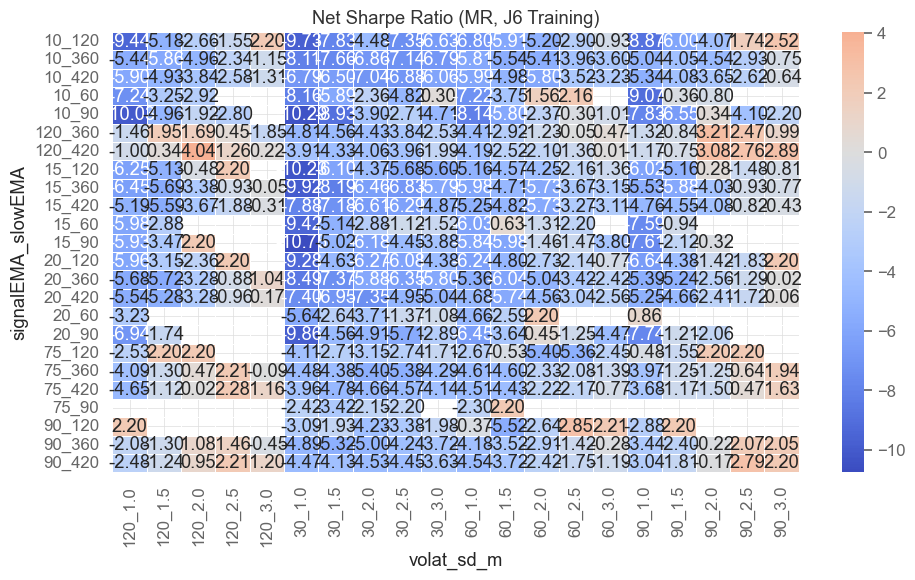

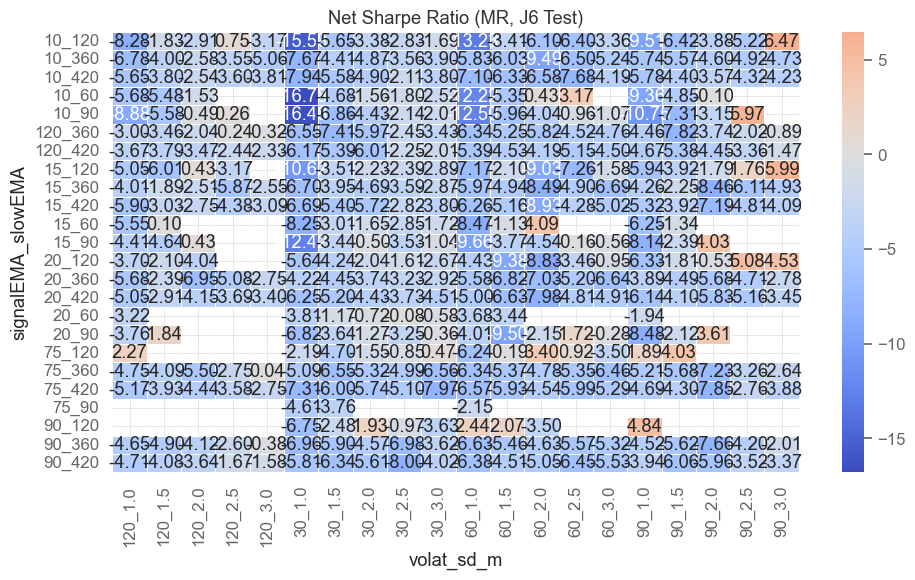

Training and test results for J6 show that, as with E6, only a narrow set of parameters yield positive net Sharpe Ratios. Most parameter combinations perform poorly, indicating high sensitivity and risk of overfitting. The best parameters in training do not always generalize to test data.


In [52]:
# 7. Compare best training and test results
best_mr_test = summary_all_breakout_J6_test.sort_values(by='net_SR_mr', ascending=False).iloc[0]
best_mom_test = summary_all_breakout_J6_test.sort_values(by='net_SR_mom', ascending=False).iloc[0]
print('Best MR test params:', best_mr_test)
print('Best MOM test params:', best_mom_test)

# 8. Visualize sensitivity (heatmap for MR)
summary_all_breakout_J6['signalEMA_slowEMA'] = summary_all_breakout_J6['signalEMA'].astype(str) + '_' + summary_all_breakout_J6['slowEMA'].astype(str)
summary_all_breakout_J6['volat_sd_m'] = summary_all_breakout_J6['volat_sd'].astype(str) + '_' + summary_all_breakout_J6['m'].astype(str)
from functions.plot_heatmap import plot_heatmap
plot_heatmap(
    summary_all_breakout_J6,
    value_col='net_SR_mr',
    index_col='signalEMA_slowEMA',
    columns_col='volat_sd_m',
    title='Net Sharpe Ratio (MR, J6 Training)',
    cmap='coolwarm'
)
# Heatmap for test
test = summary_all_breakout_J6_test.copy()
test['signalEMA_slowEMA'] = test['signalEMA'].astype(str) + '_' + test['slowEMA'].astype(str)
test['volat_sd_m'] = test['volat_sd'].astype(str) + '_' + test['m'].astype(str)
plot_heatmap(
    test,
    value_col='net_SR_mr',
    index_col='signalEMA_slowEMA',
    columns_col='volat_sd_m',
    title='Net Sharpe Ratio (MR, J6 Test)',
    cmap='coolwarm'
)

# 9. Comment on results
print('Training and test results for J6 show that, as with E6, only a narrow set of parameters yield positive net Sharpe Ratios. Most parameter combinations perform poorly, indicating high sensitivity and risk of overfitting. The best parameters in training do not always generalize to test data.')

# Exercise 7.3

Analyze a mean-reverting strategy for a spread between the Canadian dollar C6 and the Australian dollar A6 (assume the simplest form: C6-A6).

Remember that transaction costs are ALWAYS positive, regardless of whether you are long or short.

In [53]:
# Solution to Exercise 7.3: Mean-reverting strategy for C6-A6 spread

# 1. Prepare spread data for training and test
C6 = currencies_train['C6']
A6 = currencies_train['A6']
C6_test = currencies_test['C6']
A6_test = currencies_test['A6']
spread = C6 - A6
spread_test = C6_test - A6_test

# 2. Create pos_flat for spread (same trading rules)
pos_flat_spread = np.zeros(len(spread))
dweek_spread = spread.index.dayofweek + 1
time_spread = spread.index.time
pos_flat_spread[((dweek_spread == 5) & (time_spread > pd.to_datetime('17:00').time())) |
                (dweek_spread == 6) |
                ((dweek_spread == 7) & (time_spread <= pd.to_datetime('18:00').time()))] = 1
breaks_spread = (spread.index.time >= pd.to_datetime("16:46").time()) & (spread.index.time <= pd.to_datetime("18:15").time())
pos_flat_spread[breaks_spread] = 1

In [54]:


# 3. Parameter grid for mean-reverting strategy
signalEMA_parameters = [10, 15, 20, 75, 90, 120]
slowEMA_parameters = [60, 90, 120, 360, 420]
volat_sd_parameters = [30, 60, 90, 120]
m_parameters = [1, 1.5, 2, 2.5, 3]

from functions.position_VB import positionVB

# 4. Grid search for training data (spread)
summary_spread = []
for signalEMA in signalEMA_parameters:
    print(signalEMA)
    for slowEMA in slowEMA_parameters:
        if signalEMA >= slowEMA:
            continue
        for volat_sd in volat_sd_parameters:
            for m in m_parameters:
                sEMA = spread.ewm(span=signalEMA).mean().to_numpy()
                lEMA = spread.ewm(span=slowEMA).mean().to_numpy()
                vSD = spread.rolling(window=int(volat_sd)).std().to_numpy()
                sEMA[np.isnan(spread)] = np.nan
                lEMA[np.isnan(spread)] = np.nan
                vSD[np.isnan(spread)] = np.nan
                pos_mr = positionVB(signal=sEMA, lower=lEMA - m*vSD, upper=lEMA + m*vSD, pos_flat=pos_flat_spread, strategy="mr")
                # Spread point value: C6 = 100,000, A6 = 100,000
                point_value = 100000
                pnl_gross = np.where(np.isnan(pos_mr * spread.diff()), 0, pos_mr * spread.diff() * point_value)
                ntrans = np.abs(np.diff(pos_mr, prepend=0))
                # Transaction cost: $10 per leg, $20 per round-trip
                pnl_net = pnl_gross - ntrans * 20
                dates = spread.index.date
                pnl_net_d = pd.Series(pnl_net, index=dates).groupby(level=0).sum()
                def mySR(x, scale):
                    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)
                net_SR = mySR(pnl_net_d, scale=252)
                summary_spread.append({'signalEMA': signalEMA, 'slowEMA': slowEMA, 'volat_sd': volat_sd, 'm': m, 'net_SR': net_SR})
summary_spread = pd.DataFrame(summary_spread)



10
15
15
20
20
75
75
90
90
120
120


In [55]:
# 5. Find best parameters
best_spread = summary_spread.sort_values(by='net_SR', ascending=False).iloc[0]
print('Best spread MR params:', best_spread)

Best spread MR params: signalEMA    10.000000
slowEMA      60.000000
volat_sd     90.000000
m             2.000000
net_SR        3.295352
Name: 12, dtype: float64


In [56]:
# 6. Repeat for test data
pos_flat_spread_test = np.zeros(len(spread_test))
dweek_spread_test = spread_test.index.dayofweek + 1
time_spread_test = spread_test.index.time
pos_flat_spread_test[((dweek_spread_test == 5) & (time_spread_test > pd.to_datetime('17:00').time())) |
                     (dweek_spread_test == 6) |
                     ((dweek_spread_test == 7) & (time_spread_test <= pd.to_datetime('18:00').time()))] = 1
breaks_spread_test = (spread_test.index.time >= pd.to_datetime("16:46").time()) & (spread_test.index.time <= pd.to_datetime("18:15").time())
pos_flat_spread_test[breaks_spread_test] = 1

summary_spread_test = []
for signalEMA in signalEMA_parameters:
    print(signalEMA)
    for slowEMA in slowEMA_parameters:
        if signalEMA >= slowEMA:
            continue
        for volat_sd in volat_sd_parameters:
            for m in m_parameters:
                sEMA = spread_test.ewm(span=signalEMA).mean().to_numpy()
                lEMA = spread_test.ewm(span=slowEMA).mean().to_numpy()
                vSD = spread_test.rolling(window=int(volat_sd)).std().to_numpy()
                sEMA[np.isnan(spread_test)] = np.nan
                lEMA[np.isnan(spread_test)] = np.nan
                vSD[np.isnan(spread_test)] = np.nan
                pos_mr = positionVB(signal=sEMA, lower=lEMA - m*vSD, upper=lEMA + m*vSD, pos_flat=pos_flat_spread_test, strategy="mr")
                point_value = 100000
                pnl_gross = np.where(np.isnan(pos_mr * spread_test.diff()), 0, pos_mr * spread_test.diff() * point_value)
                ntrans = np.abs(np.diff(pos_mr, prepend=0))
                pnl_net = pnl_gross - ntrans * 20
                dates = spread_test.index.date
                pnl_net_d = pd.Series(pnl_net, index=dates).groupby(level=0).sum()
                net_SR = mySR(pnl_net_d, scale=252)
                summary_spread_test.append({'signalEMA': signalEMA, 'slowEMA': slowEMA, 'volat_sd': volat_sd, 'm': m, 'net_SR': net_SR})
summary_spread_test = pd.DataFrame(summary_spread_test)



10
15
15
20
20
75
75
90
90
120
120


In [57]:
# 7. Compare best training and test results
best_spread_test = summary_spread_test.sort_values(by='net_SR', ascending=False).iloc[0]
print('Best spread MR test params:', best_spread_test)

Best spread MR test params: signalEMA    75.000000
slowEMA      90.000000
volat_sd     30.000000
m             2.000000
net_SR        4.508292
Name: 302, dtype: float64


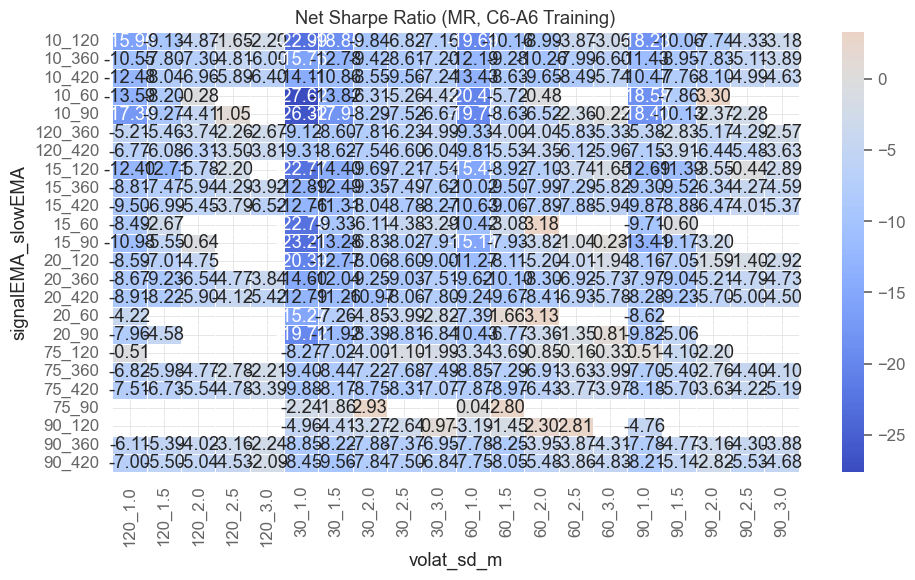

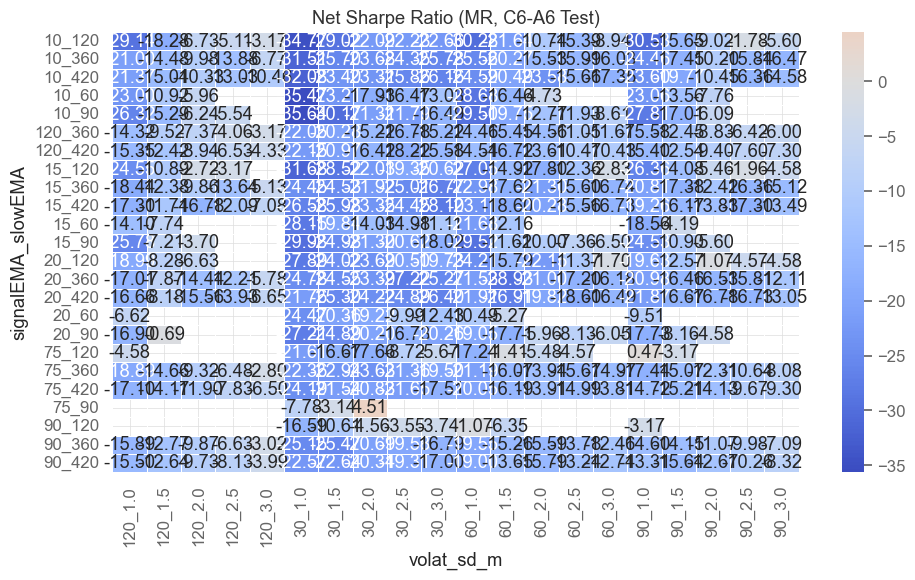

For the C6-A6 spread, as with single assets, only a narrow set of parameters yield positive net Sharpe Ratios. Most parameter combinations perform poorly, indicating high sensitivity and risk of overfitting. The best parameters in training do not always generalize to test data. Transaction costs for both legs are always included.


In [58]:


# 8. Visualize sensitivity (heatmap)
summary_spread['signalEMA_slowEMA'] = summary_spread['signalEMA'].astype(str) + '_' + summary_spread['slowEMA'].astype(str)
summary_spread['volat_sd_m'] = summary_spread['volat_sd'].astype(str) + '_' + summary_spread['m'].astype(str)
from functions.plot_heatmap import plot_heatmap
plot_heatmap(
    summary_spread,
    value_col='net_SR',
    index_col='signalEMA_slowEMA',
    columns_col='volat_sd_m',
    title='Net Sharpe Ratio (MR, C6-A6 Training)',
    cmap='coolwarm'
)
test = summary_spread_test.copy()
test['signalEMA_slowEMA'] = test['signalEMA'].astype(str) + '_' + test['slowEMA'].astype(str)
test['volat_sd_m'] = test['volat_sd'].astype(str) + '_' + test['m'].astype(str)
plot_heatmap(
    test,
    value_col='net_SR',
    index_col='signalEMA_slowEMA',
    columns_col='volat_sd_m',
    title='Net Sharpe Ratio (MR, C6-A6 Test)',
    cmap='coolwarm'
)

# 9. Comment on results
print('For the C6-A6 spread, as with single assets, only a narrow set of parameters yield positive net Sharpe Ratios. Most parameter combinations perform poorly, indicating high sensitivity and risk of overfitting. The best parameters in training do not always generalize to test data. Transaction costs for both legs are always included.')